In [1]:
import os, io, base64, re, json, math
from pathlib import Path
from typing import List, Optional, Literal
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import fitz  # PyMuPDF
from PIL import Image
from pydantic import BaseModel, Field
from dotenv import load_dotenv

load_dotenv()

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

llm    = ChatOpenAI(model="gpt-4o-mini")
vision = ChatOpenAI(model="gpt-4o-mini", max_tokens=500)
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")


/home/oncreative/anaconda3/envs/modu/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.3.0) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(


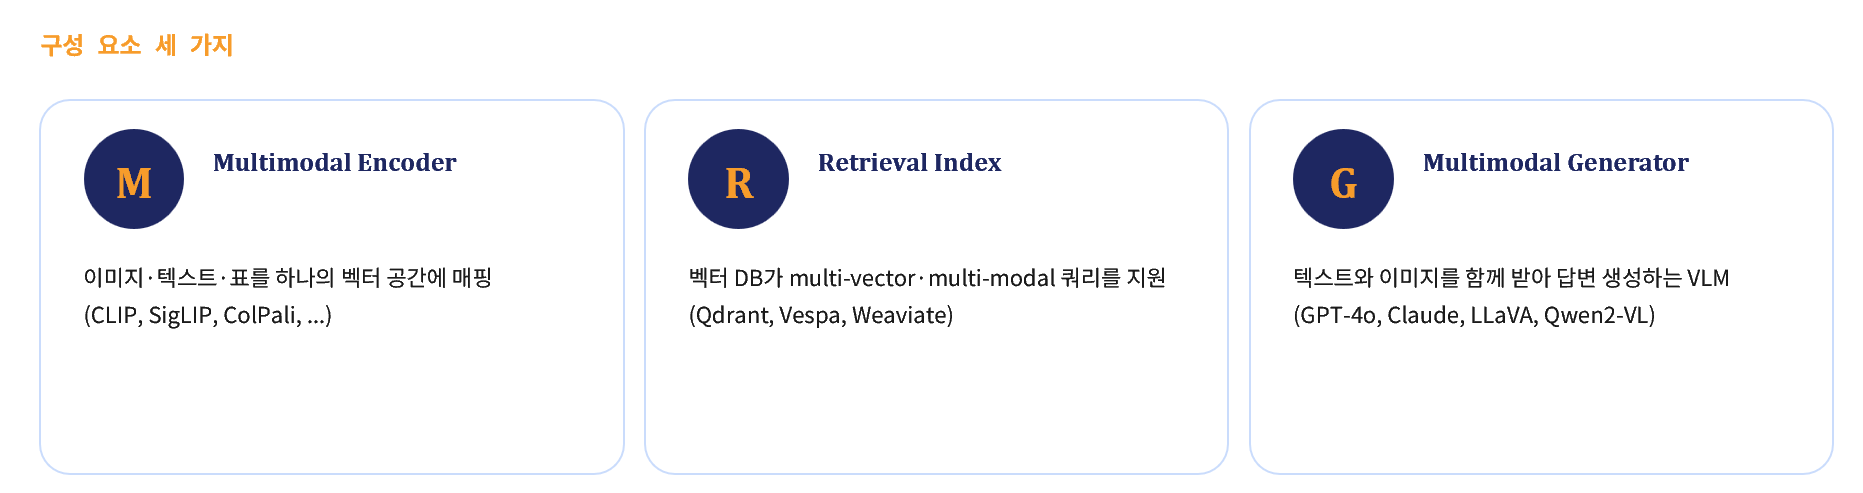

In [2]:
def image_to_data_uri(image_or_path) -> str:
    if isinstance(image_or_path, (str, Path)):
        img = Image.open(image_or_path)
    else:
        img = image_or_path
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    return f"data:image/png;base64,{base64.b64encode(buf.getvalue()).decode()}"



In [3]:
IMAGE_DIR = Path('data/images')

In [4]:
img = Image.open(IMAGE_DIR / 'ir_report_page.png')
data_uri = image_to_data_uri(img)

In [7]:
# data_uri

In [8]:
msg = HumanMessage(content = [
    {'type' : 'text', 'text' : '이 IR 보고서의 핵심 지표 3개를 한 줄씩 알려줘'},
    {'type' : 'image_url', 'image_url' : {'url' : data_uri, 'detail' : 'high'}}
])
r = vision.invoke([msg])

In [10]:
r.content

'1. **Revenue**: $1.865B, an increase of 18% YoY.\n2. **Operating Income**: $245M, up by 35% YoY.\n3. **AI Division Revenue**: $980M, reflecting a 45% increase YoY.'

In [11]:
chart = Image.open(IMAGE_DIR / "chart_monthly_sales.png")

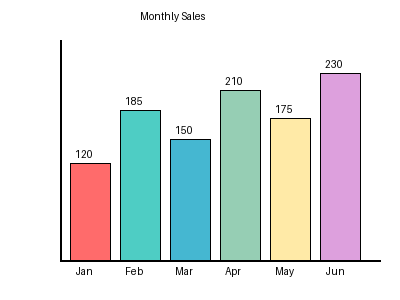

In [12]:
chart

In [14]:
def build_vision_message(text : str, images : list, detail : str = 'auto') -> HumanMessage:
    content = [{'type' : 'text', 'text': text}]
    for img in images:
        uri = image_to_data_uri(img)
        content.append({'type' : 'image_url', 'image_url' : {'url' : uri, 'detail' : detail}})
    
    return HumanMessage(content=content)

In [16]:
prompts = ['이 이미지를 설명해줘', '이 막대 차트의 각 막대 값을 `| 월 | 값` Markdown 표로. 마지막에 추세 한 줄 요약해줘']
for p in prompts:
    msg = build_vision_message(p, [chart], detail='high')
    r = vision.invoke([msg])
    print(r.content)
    print('======')

이 이미지는 월별 판매량을 나타낸 막대그래프입니다. 각 월의 판매량은 다음과 같습니다:

- **1월**: 120
- **2월**: 185
- **3월**: 150
- **4월**: 210
- **5월**: 175
- **6월**: 230

4월과 6월의 판매량이 가장 높고, 1월의 판매량이 가장 낮습니다. 그래프는 판매량의 추세를 한눈에 보여줍니다.
아래는 막대 차트의 각 월과 그에 해당하는 값입니다.

| 월   | 값  |
|------|-----|
| Jan  | 120 |
| Feb  | 185 |
| Mar  | 150 |
| Apr  | 210 |
| May  | 175 |
| Jun  | 230 |

### 추세 요약
매출은 전반적으로 증가하는 추세를 보이며, 특히 6월에 가장 높은 값을 기록했습니다.


In [17]:
def build_extraction_prompt(image_type):
    prompts = {
        'chart' : '이 차트의 각 항목 값을 json으로 추출 : {"title" : "", "data" : [{"label" :"", "value":0}], "trend":""}',
        'invoice' :'이 인보이스 정보를 json으로 추출 : {"invoice_no":"", "data" :"", "items" :[{"name":"","qty":0, "total":""}], "total":""}',
        'document' : '이 문서의 정보를 json으로 추출 : {"title":"", "summary":"", "key_points":[]}'
    }
    
    return prompts.get(image_type, '이 이미지의 핵심 내용을 3줄로 요약해주세요')

In [19]:
# build_extraction_prompt
# build_vision_message

def analyze_image_typed(image_path, image_type) -> dict:
    prompt = build_extraction_prompt(image_type)
    msg = build_vision_message(prompt, [image_path], detail='high')
    text = vision.invoke([msg]).content.strip()
    
    if "```" in text:
        text = text.split("```")[1].replace("json", "").strip()
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        return {'raw_text' : text, 'error' : 'failed'}
        
    
#     return 
# {"title":"", "summary":"", "key_points":[]}

In [21]:
analyze_image_typed(str(IMAGE_DIR / 'chart_monthly_sales.png'), 'chart')

{'title': 'Monthly Sales',
 'data': [{'label': 'Jan', 'value': 120},
  {'label': 'Feb', 'value': 185},
  {'label': 'Mar', 'value': 150},
  {'label': 'Apr', 'value': 210},
  {'label': 'May', 'value': 175},
  {'label': 'Jun', 'value': 230}],
 'trend': 'increasing'}

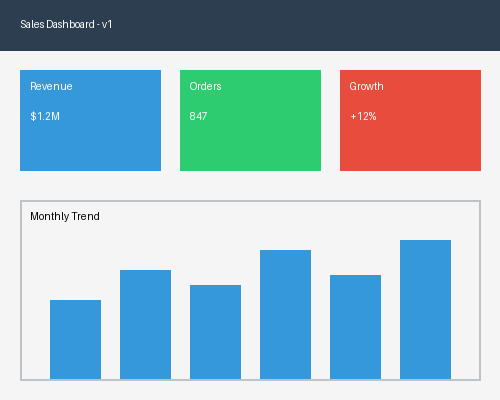

In [22]:
dashboard = Image.open(IMAGE_DIR / 'dashboard_v1.png')
dashboard

In [23]:
history = [SystemMessage(content = '당신은 데이터 분석가입니다. 주어진 대시보드를 분석해주세요')]
questions = [
    "이 대시보드의 핵심 지표 3가지를 알려줘",
    "Revenue와 Orders 사이의 비율은?",
    "이 추세대로면 다음 분기는 어떨까?"
]

for i, q in enumerate(questions,1):
    if i==1:
        history.append(build_vision_message(q, [dashboard], detail='high'))
    else:
        history.append(HumanMessage(content=q))
    
    ans = vision.invoke(history).content
    history.append(AIMessage(content=ans))
    print(f"\n[Turn {i}] Q ; {q}")
    print(f" A : {ans}")


[Turn 1] Q ; 이 대시보드의 핵심 지표 3가지를 알려줘
 A : 대시보드의 핵심 지표 3가지는 다음과 같습니다:

1. **수익 (Revenue)**: $1.2M
2. **주문 수 (Orders)**: 847
3. **성장률 (Growth)**: +12% 

이 지표들은 판매 성과를 평가하는 데 중요한 정보를 제공합니다.

[Turn 2] Q ; Revenue와 Orders 사이의 비율은?
 A : Revenue와 Orders 사이의 비율은 다음과 같이 계산할 수 있습니다:

- Revenue: $1.2M (1,200,000)
- Orders: 847

비율 계산식은 다음과 같습니다:

\[
\text{비율} = \frac{\text{Revenue}}{\text{Orders}} = \frac{1,200,000}{847} \approx 1417.2
\]

따라서 Revenue와 Orders 사이의 비율은 약 1417.2입니다. 이는 평균적으로 한 주문당 약 $1417.2의 수익이 발생했음을 의미합니다.

[Turn 3] Q ; 이 추세대로면 다음 분기는 어떨까?
 A : 현재 성장률이 +12%인 상황에서, 다음 분기의 예상 수익과 주문 수를 계산해볼 수 있습니다.

1. **다음 분기 수익 예상**:
   - 현재 수익: $1.2M
   - 예상 성장률: 12%

계산식:
\[
\text{다음 분기 수익} = 1.2M \times (1 + 0.12) = 1.2M \times 1.12 \approx 1.3344M
\]

2. **다음 분기 주문 수 예상**:
   - 현재 주문 수: 847
   - 성장은 상황에 따라 다를 수 있지만, 비슷한 성장률을 가정할 경우, 주문 수에도 12% 증가가 예상됩니다.

계산식:
\[
\text{다음 분기 주문 수} = 847 \times (1 + 0.12) \approx 847 \times 1.12 \approx 950
\]

따라서, 다음 분기의 예상 수익은 약 $1.3344M, 주문 수는 약 950개가 될 것입니

In [25]:
def first_turn(image, message) -> HumanMessage:
    return build_vision_message(message, [image], detail="auto")

# def continue_turn(~~)

In [26]:
v1 = Image.open(IMAGE_DIR / 'dashboard_v1.png')
v2 = Image.open(IMAGE_DIR / 'dashboard_v2.png')

In [28]:
v1.save('aaa.png')

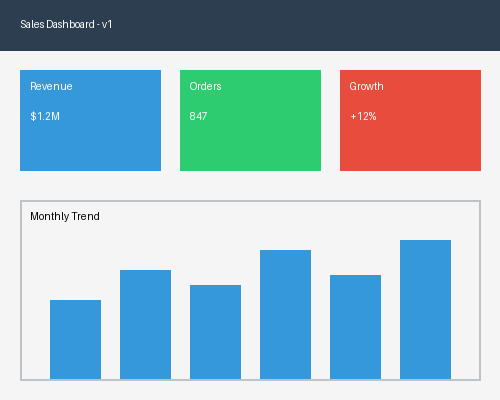

In [30]:
v1

In [35]:
v1.size, v2.size

((500, 400), (500, 400))

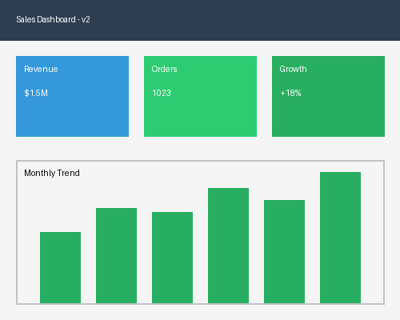

In [36]:
v1.resize((400, 320))
v2.resize((400, 320))

In [31]:
# clip qwen -> size, shape
msg = build_vision_message("두 대시보드의 변경 사항을 (1) 수치 변화 (2) 시각적 변화 두 섹션으로 정리해줘",
                          [v1, v2], detail='high')

In [32]:
r = vision.invoke([msg])

In [34]:
print(r.content)

### 1. 수치 변화
- **Revenue**: 
  - v1: $1.2M 
  - v2: $1.5M 
  - **변화**: +$300K

- **Orders**: 
  - v1: 847 
  - v2: 1023 
  - **변화**: +176

- **Growth**: 
  - v1: +12% 
  - v2: +18% 
  - **변화**: +6pp (percentage points)

### 2. 시각적 변화
- **대시보드 배경 색상**: v1의 배경은 하얀색이며, v2에서는 동일하게 유지됨.
- **Revenue, Orders, Growth 상자 색상**: 
  - Revenue와 Orders 상자 색상은 동일 (파란색과 초록색).
  - Growth 상자는 버전 1에서 빨간색, 버전 2에서는 초록색으로 변경됨.
- **Monthly Trend 그래프**: 
  - v1의 그래프가 파란색 막대기로 표시된 반면, v2에서는 초록색 막대기로 변경됨.
- **그래프의 막대 높이**: v2에서 전체적으로 막대가 더 높아져 성과가 개선된 것을 시각적으로 보여줌.
